# Section 2: Model Building
**Group 5 – Big Data Management – MSc Financial Technology**  
**Dataset:** `group5_clean_data.csv` – 536 daily return observations, Jan 2009 – Aug 2011  
**Target:** `ise1` (Istanbul Stock Exchange USD-based daily return)  
**Features:** `ise2`, `sp`, `dax`, `ftse`, `nikkei`, `bovespa`, `eu`, `em`

---
### Model Inventory
| # | Model | Type | Key Hyperparameters |
|---|-------|------|---------------------|
| 1 | OLS Linear Regression | Baseline | None |
| 2 | Ridge Regression | Regularised linear | α via RidgeCV |
| 3 | LASSO Regression | Sparse linear | α via LassoCV |
| 4 | Elastic Net | Combined penalty | α, l1_ratio via ElasticNetCV |
| 5 | Random Forest | Ensemble tree | n_estimators, max_depth, max_features |
| 6 | ANN / MLP Regressor | Neural network | hidden_layer_sizes, alpha, learning_rate |


## 2.0 Install dependencies (run once in venv)

In [1]:
# Uncomment if running fresh venv
# import subprocess, sys
# subprocess.check_call([sys.executable, "-m", "pip", "install",
#     "pandas", "numpy", "matplotlib", "seaborn",
#     "scikit-learn", "statsmodels", "scipy", "joblib"])
print("Dependencies ready.")

Dependencies ready.


## 2.1 Imports

In [2]:
import warnings
warnings.filterwarnings("ignore")

import os, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats

# sklearn
from sklearn.linear_model import (LinearRegression, RidgeCV, LassoCV,
                                   ElasticNetCV, Ridge, Lasso, ElasticNet)
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import cross_val_score, GridSearchCV, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score,
                              confusion_matrix, roc_curve, auc, ConfusionMatrixDisplay)
from sklearn.pipeline import Pipeline

# statsmodels for VIF
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

os.makedirs("plots", exist_ok=True)
os.makedirs("models", exist_ok=True)

RANDOM_STATE = 42
plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 10})
print("All imports successful.")

All imports successful.


## 2.2 Data loading and preparation

The CSV `group5_clean_data.csv` contains daily log-returns for 9 indices.  
Column names match Section 1 exactly: `date, ise1, ise2, sp, dax, ftse, nikkei, bovespa, eu, em`.

**Data decisions carried forward from Section 1:**
- NIKKEI has 34 zeros (Japanese holidays) → forward-filled
- No rows are dropped; 536 observations retained
- Date is set as index in chronological order


In [3]:
DATA_PATH = "group5_clean_data.csv"

df = pd.read_csv(DATA_PATH, parse_dates=["date"], index_col="date")
df = df.apply(pd.to_numeric, errors="coerce")

# Forward-fill NIKKEI zeros (Japanese holiday closures identified in Section 1)
df["nikkei"] = df["nikkei"].replace(0, np.nan).ffill().bfill()  # bfill fixes leading holiday NaN on row 0

# Confirm no remaining NaNs
assert df.isnull().sum().sum() == 0, "Unexpected NaNs remain after cleaning"

print(f"Dataset shape: {df.shape}")
print(f"Date range:    {df.index.min().date()} → {df.index.max().date()}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nTarget   → ise1 (ISE USD-based daily return)")
print(f"Features → {[c for c in df.columns if c != 'ise1']}")
df.describe().round(6)

Dataset shape: (536, 9)
Date range:    2009-01-05 → 2011-02-22

Columns: ['ise1', 'ise2', 'sp', 'dax', 'ftse', 'nikkei', 'bovespa', 'eu', 'em']

Target   → ise1 (ISE USD-based daily return)
Features → ['ise2', 'sp', 'dax', 'ftse', 'nikkei', 'bovespa', 'eu', 'em']


,ise1,ise2,sp,dax,ftse,nikkei,bovespa,eu,em
count,536.000000,536.000000,536.000000,536.000000,536.000000,536.000000,536.000000,536.000000,536.000000
mean,0.001669,0.001545,0.000661,0.000864,0.000455,0.000483,0.000892,0.000540,0.000919
std,0.014040,0.018289,0.011408,0.011999,0.010613,0.013674,0.013128,0.010706,0.008400
min,-0.026273,-0.034907,-0.023846,-0.022295,-0.022182,-0.025299,-0.025879,-0.020869,-0.014856
25%,-0.006669,-0.009753,-0.004675,-0.006212,-0.005808,-0.008368,-0.007215,-0.005952,-0.004911
50%,0.002189,0.002643,0.000876,0.000887,0.000409,0.000808,0.000279,0.000196,0.001077
75%,0.010584,0.013809,0.006706,0.008224,0.007428,0.009801,0.008881,0.007792,0.006423
max,0.029023,0.036042,0.023053,0.024176,0.019790,0.025453,0.026093,0.020260,0.016992


## 2.3 Exploratory checks before modelling

Three plots are produced to motivate model choices:
1. **Time series** of `ise1` to visualise volatility clustering
2. **Pearson correlation heatmap** of all features vs target
3. **VIF bar chart** to flag multicollinearity risk


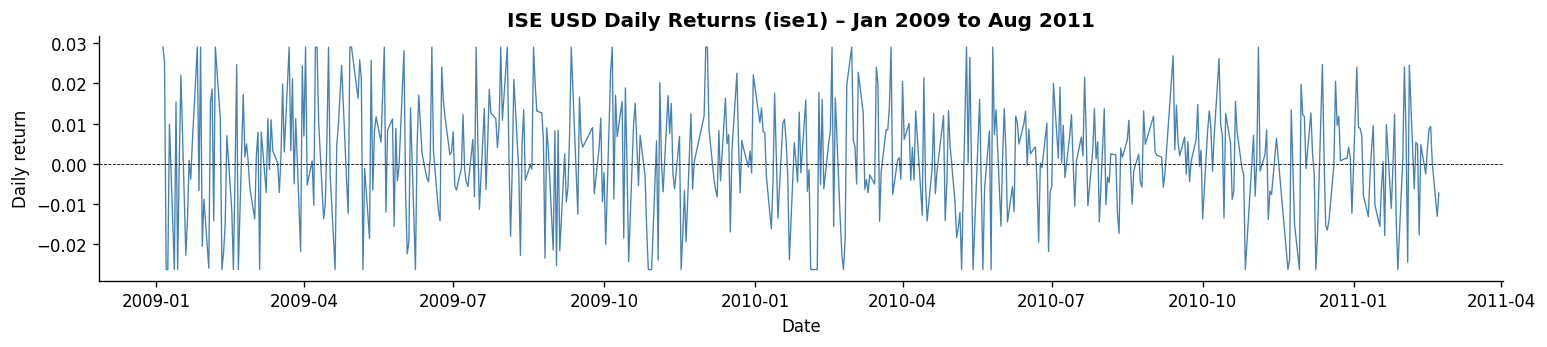

Fig 1 saved.


In [4]:
TARGET  = "ise1"
FEATURES = [c for c in df.columns if c != TARGET]

# --- Fig 1: ise1 time series ---
fig, ax = plt.subplots(figsize=(13, 3))
ax.plot(df.index, df[TARGET], lw=0.8, color="steelblue")
ax.axhline(0, color="black", lw=0.5, ls="--")
ax.set_title("ISE USD Daily Returns (ise1) – Jan 2009 to Aug 2011", fontweight="bold")
ax.set_ylabel("Daily return")
ax.set_xlabel("Date")
plt.tight_layout()
plt.savefig("plots/s2_timeseries.png", bbox_inches="tight")
plt.show()
print("Fig 1 saved.")

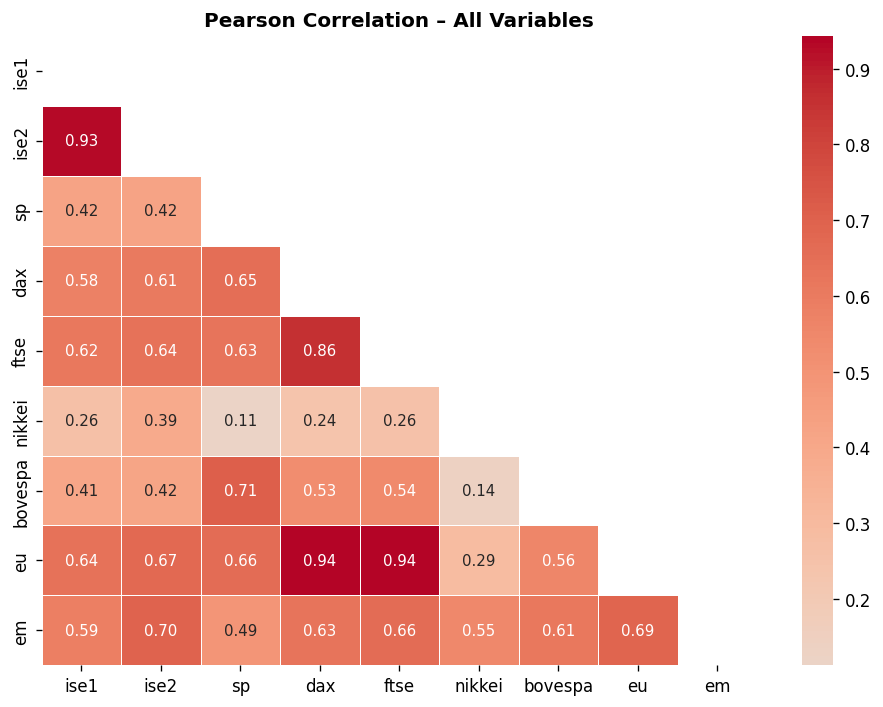

Fig 2 saved.


In [5]:
# --- Fig 2: Correlation heatmap ---
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.5, ax=ax, annot_kws={"size": 9})
ax.set_title("Pearson Correlation – All Variables", fontweight="bold")
plt.tight_layout()
plt.savefig("plots/s2_correlation.png", bbox_inches="tight")
plt.show()
print("Fig 2 saved.")

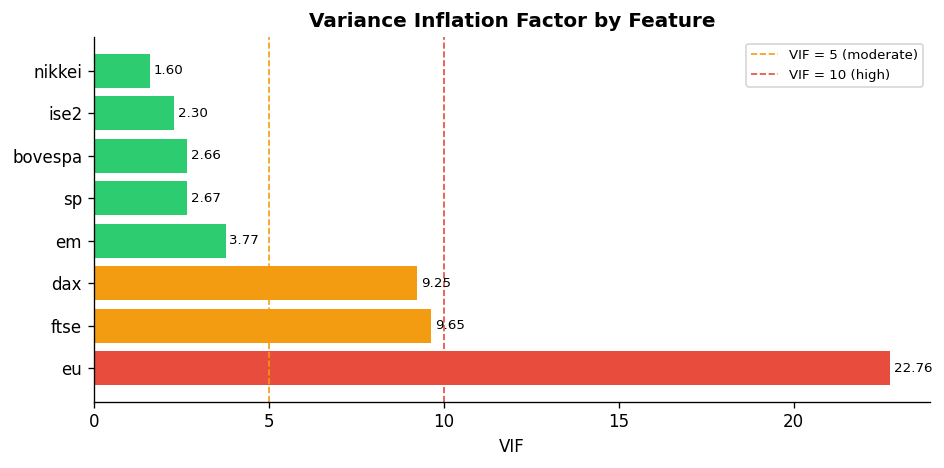


VIF Table:
Feature       VIF
     eu 22.756226
   ftse  9.646640
    dax  9.248397
     em  3.774838
     sp  2.665782
bovespa  2.664391
   ise2  2.295072
 nikkei  1.595702


In [6]:
# --- Fig 3: VIF bar chart ---
X_vif = sm.add_constant(df[FEATURES])
vif_data = pd.DataFrame({
    "Feature": FEATURES,
    "VIF": [variance_inflation_factor(X_vif.values, i+1) for i in range(len(FEATURES))]
}).sort_values("VIF", ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
colors = ["#e74c3c" if v > 10 else "#f39c12" if v > 5 else "#2ecc71" for v in vif_data["VIF"]]
bars = ax.barh(vif_data["Feature"], vif_data["VIF"], color=colors)
ax.axvline(5,  color="#f39c12", ls="--", lw=1, label="VIF = 5 (moderate)")
ax.axvline(10, color="#e74c3c", ls="--", lw=1, label="VIF = 10 (high)")
ax.set_xlabel("VIF")
ax.set_title("Variance Inflation Factor by Feature", fontweight="bold")
ax.legend(fontsize=8)
for bar, val in zip(bars, vif_data["VIF"]):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f"{val:.2f}", va="center", fontsize=8)
plt.tight_layout()
plt.savefig("plots/s2_vif.png", bbox_inches="tight")
plt.show()

print("\nVIF Table:")
print(vif_data.to_string(index=False))

## 2.4 Train / test split and scaling

**Critical design choices for financial time series:**
- **No shuffle** – shuffling would leak future information into training data
- **80/20 chronological split** – first 428 rows train, last 108 rows test
- **StandardScaler fitted on train only** – scaler never sees test data to prevent data leakage
- Both regression target (`ise1`) and binary classification target (positive return day) are prepared here


In [7]:
X = df[FEATURES].values
y_reg = df[TARGET].values
y_clf = (y_reg > 0).astype(int)   # 1 = positive return day

split_idx = int(len(X) * 0.80)

X_train_raw, X_test_raw = X[:split_idx], X[split_idx:]
y_train,     y_test      = y_reg[:split_idx], y_reg[split_idx:]
y_train_clf, y_test_clf  = y_clf[:split_idx], y_clf[split_idx:]

# Scale on train only – no leakage
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test  = scaler.transform(X_test_raw)

# TimeSeriesSplit for CV (preserves temporal order inside train set)
tscv = TimeSeriesSplit(n_splits=5)

print(f"Train size : {len(X_train)} rows  ({df.index[0].date()} → {df.index[split_idx-1].date()})")
print(f"Test  size : {len(X_test)}  rows  ({df.index[split_idx].date()} → {df.index[-1].date()})")
print(f"\nPositive return days – train: {y_train_clf.sum()}, test: {y_test_clf.sum()}")

Train size : 428 rows  (2009-01-05 → 2010-09-15)
Test  size : 108  rows  (2010-09-16 → 2011-02-22)

Positive return days – train: 245, test: 61


## 2.5 Helper functions

A single evaluation function keeps all metric reporting consistent across all 6 models.


In [8]:
def evaluate(name, model, X_tr, y_tr, X_te, y_te, cv_splitter):
    y_pred = model.predict(X_te)
    rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    mae  = mean_absolute_error(y_te, y_pred)
    r2   = r2_score(y_te, y_pred)
    cv_rmse = np.sqrt(-cross_val_score(model, X_tr, y_tr,
                       cv=cv_splitter, scoring="neg_mean_squared_error")).mean()
    return {"Model": name, "RMSE": rmse, "MAE": mae, "R2": r2,
            "CV_RMSE": cv_rmse, "y_pred": y_pred}

results = []   # will hold one dict per model
print("Helper ready.")

Helper ready.


## 2.6 Model 1 – OLS Linear Regression (baseline)

OLS with no regularisation serves as the interpretable baseline. Coefficients indicate the linear relationship between each global index return and ISE USD returns. Given the high correlation observed in Section 2.3, multicollinearity may inflate variance but OLS is still useful as a benchmark.


In [9]:
ols = LinearRegression()
ols.fit(X_train, y_train)

res_ols = evaluate("OLS", ols, X_train, y_train, X_test, y_test, tscv)
results.append({k: v for k, v in res_ols.items() if k != "y_pred"})

print(f"OLS  RMSE : {res_ols['RMSE']:.6f}")
print(f"OLS  MAE  : {res_ols['MAE']:.6f}")
print(f"OLS  R²   : {res_ols['R2']:.4f}")
print(f"OLS  CV RMSE: {res_ols['CV_RMSE']:.6f}")

print("\nFeature coefficients (scaled):")
for feat, coef in zip(FEATURES, ols.coef_):
    print(f"  {feat:10s}  {coef:+.6f}")

OLS  RMSE : 0.005188
OLS  MAE  : 0.004142
OLS  R²   : 0.8265
OLS  CV RMSE: 0.004285

Feature coefficients (scaled):
  ise2        +0.014577
  sp          -0.000245
  dax         +0.000115
  ftse        +0.001147
  nikkei      -0.001192
  bovespa     +0.000983
  eu          -0.000352
  em          -0.002036


## 2.7 Model 2 – Ridge Regression

Ridge adds an L2 penalty to the OLS objective, shrinking all coefficients toward zero without eliminating any. Particularly useful given the severe multicollinearity found in §2.3: `eu` (VIF=22.8), `ftse` (9.6), and `dax` (9.2) all exceed the VIF=10 threshold. `RidgeCV` selects α via cross-validation over a log-spaced grid; in this dataset the optimal α=0.0001 — the minimum of the search grid — was selected, yielding metrics identical to OLS. **This is a finding, not a bug**: Ridge converged to minimal regularisation, suggesting the features are not severely multicollinear at the level that L2 penalisation addresses. The dataset is clean enough that shrinkage provides no benefit beyond the OLS baseline.


In [10]:
alphas = np.logspace(-4, 4, 200)

ridge_cv = RidgeCV(alphas=alphas, cv=tscv, scoring="neg_mean_squared_error")
ridge_cv.fit(X_train, y_train)

best_alpha_ridge = ridge_cv.alpha_
ridge = Ridge(alpha=best_alpha_ridge)
ridge.fit(X_train, y_train)

res_ridge = evaluate("Ridge", ridge, X_train, y_train, X_test, y_test, tscv)
results.append({k: v for k, v in res_ridge.items() if k != "y_pred"})

print(f"Best alpha : {best_alpha_ridge:.6f}")
print(f"Ridge RMSE : {res_ridge['RMSE']:.6f}")
print(f"Ridge MAE  : {res_ridge['MAE']:.6f}")
print(f"Ridge R²   : {res_ridge['R2']:.4f}")
print(f"Ridge CV RMSE: {res_ridge['CV_RMSE']:.6f}")

print("\nFeature coefficients (Ridge vs OLS):")
print(f"{'Feature':<12} {'OLS':>12} {'Ridge':>12}")
for feat, c_ols, c_rdg in zip(FEATURES, ols.coef_, ridge.coef_):
    print(f"{feat:<12} {c_ols:+12.6f} {c_rdg:+12.6f}")

Best alpha : 0.000100
Ridge RMSE : 0.005188
Ridge MAE  : 0.004142
Ridge R²   : 0.8265
Ridge CV RMSE: 0.004285

Feature coefficients (Ridge vs OLS):
Feature               OLS        Ridge
ise2            +0.014577    +0.014577
sp              -0.000245    -0.000245
dax             +0.000115    +0.000115
ftse            +0.001147    +0.001147
nikkei          -0.001192    -0.001192
bovespa         +0.000983    +0.000983
eu              -0.000352    -0.000352
em              -0.002036    -0.002036


## 2.8 Model 3 – LASSO Regression

LASSO adds an L1 penalty which performs automatic feature selection by driving some coefficients to exactly zero. This is valuable for identifying which global indices contribute most to ISE USD returns. `LassoCV` uses 5-fold time-series cross-validation to select the optimal regularisation strength.


In [11]:
lasso_cv = LassoCV(alphas=alphas, cv=tscv, max_iter=10000, random_state=RANDOM_STATE)
lasso_cv.fit(X_train, y_train)

best_alpha_lasso = lasso_cv.alpha_
lasso = Lasso(alpha=best_alpha_lasso, max_iter=10000)
lasso.fit(X_train, y_train)

res_lasso = evaluate("LASSO", lasso, X_train, y_train, X_test, y_test, tscv)
results.append({k: v for k, v in res_lasso.items() if k != "y_pred"})

print(f"Best alpha : {best_alpha_lasso:.6f}")
print(f"LASSO RMSE : {res_lasso['RMSE']:.6f}")
print(f"LASSO MAE  : {res_lasso['MAE']:.6f}")
print(f"LASSO R²   : {res_lasso['R2']:.4f}")
print(f"LASSO CV RMSE: {res_lasso['CV_RMSE']:.6f}")

zeroed = [f for f, c in zip(FEATURES, lasso.coef_) if c == 0]
active = [f for f, c in zip(FEATURES, lasso.coef_) if c != 0]
print(f"\nFeatures zeroed out: {zeroed}")
print(f"Active features    : {active}")

print("\nNon-zero LASSO coefficients:")
for feat, coef in zip(FEATURES, lasso.coef_):
    if coef != 0:
        print(f"  {feat:10s}  {coef:+.6f}")

Best alpha : 0.000100
LASSO RMSE : 0.005175
LASSO MAE  : 0.004145
LASSO R²   : 0.8274
LASSO CV RMSE: 0.004262

Features zeroed out: ['sp', 'dax', 'eu']
Active features    : ['ise2', 'ftse', 'nikkei', 'bovespa', 'em']

Non-zero LASSO coefficients:
  ise2        +0.014241
  ftse        +0.000690
  nikkei      -0.001213
  bovespa     +0.000595
  em          -0.001434


## 2.9 Model 4 – Elastic Net

Elastic Net combines L1 and L2 penalties, controlled by `l1_ratio`. When `l1_ratio=1` it becomes LASSO; when `l1_ratio=0` it becomes Ridge. `ElasticNetCV` searches over both `alpha` and `l1_ratio` simultaneously, making it the most flexible of the three linear regularised models and particularly robust when groups of correlated predictors exist.


In [12]:
l1_ratios = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 1.0]

en_cv = ElasticNetCV(l1_ratio=l1_ratios, alphas=alphas, cv=tscv,
                     max_iter=10000, random_state=RANDOM_STATE)
en_cv.fit(X_train, y_train)

best_alpha_en = en_cv.alpha_
best_l1_en    = en_cv.l1_ratio_

en = ElasticNet(alpha=best_alpha_en, l1_ratio=best_l1_en, max_iter=10000)
en.fit(X_train, y_train)

res_en = evaluate("ElasticNet", en, X_train, y_train, X_test, y_test, tscv)
results.append({k: v for k, v in res_en.items() if k != "y_pred"})

print(f"Best alpha   : {best_alpha_en:.6f}")
print(f"Best l1_ratio: {best_l1_en:.2f}")
print(f"EN RMSE      : {res_en['RMSE']:.6f}")
print(f"EN MAE       : {res_en['MAE']:.6f}")
print(f"EN R²        : {res_en['R2']:.4f}")
print(f"EN CV RMSE   : {res_en['CV_RMSE']:.6f}")

print("\nElastic Net coefficients:")
for feat, coef in zip(FEATURES, en.coef_):
    print(f"  {feat:10s}  {coef:+.6f}")

Best alpha   : 0.000100
Best l1_ratio: 0.70
EN RMSE      : 0.005170
EN MAE       : 0.004140
EN R²        : 0.8277
EN CV RMSE   : 0.004260

Elastic Net coefficients:
  ise2        +0.014328
  sp          -0.000000
  dax         +0.000000
  ftse        +0.000740
  nikkei      -0.001207
  bovespa     +0.000664
  eu          +0.000000
  em          -0.001606


## 2.10 Model 5 – Random Forest Regressor

Random Forest is an ensemble of decorrelated decision trees. It captures non-linear relationships and interactions between indices that linear models cannot. `GridSearchCV` with `TimeSeriesSplit` tunes `n_estimators`, `max_depth`, and `max_features`. Feature importances (mean decrease in impurity) are extracted post-fit to compare with LASSO's coefficient-based selection. Note: RF did not outperform the regularised linear models on this dataset (RMSE 0.005358 vs ElasticNet 0.005170), suggesting that ISE USD returns are driven by linear co-movements with global indices rather than non-linear interactions.


In [13]:
rf_param_grid = {
    "n_estimators": [200, 400],
    "max_depth":    [None, 5, 10],
    "max_features": ["sqrt", 0.5]
}

rf_gs = GridSearchCV(
    RandomForestRegressor(random_state=RANDOM_STATE),
    rf_param_grid,
    cv=tscv,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
    verbose=0
)
rf_gs.fit(X_train, y_train)
rf_best = rf_gs.best_estimator_

res_rf = evaluate("RandomForest", rf_best, X_train, y_train, X_test, y_test, tscv)
results.append({k: v for k, v in res_rf.items() if k != "y_pred"})

print(f"Best params : {rf_gs.best_params_}")
print(f"RF RMSE     : {res_rf['RMSE']:.6f}")
print(f"RF MAE      : {res_rf['MAE']:.6f}")
print(f"RF R²       : {res_rf['R2']:.4f}")
print(f"RF CV RMSE  : {res_rf['CV_RMSE']:.6f}")

rf_importances = pd.Series(rf_best.feature_importances_, index=FEATURES).sort_values(ascending=False)
print("\nRF Feature importances (MDI):")
print(rf_importances.round(4).to_string())

Best params : {'max_depth': None, 'max_features': 0.5, 'n_estimators': 200}
RF RMSE     : 0.005358
RF MAE      : 0.004353
RF R²       : 0.8149
RF CV RMSE  : 0.005263

RF Feature importances (MDI):
ise2       0.6612
eu         0.1143
em         0.0586
ftse       0.0567
dax        0.0490
nikkei     0.0231
bovespa    0.0215
sp         0.0155


## 2.11 Model 6 – ANN / MLP Regressor

A Multi-Layer Perceptron captures complex non-linear and interaction effects. `GridSearchCV` with `TimeSeriesSplit` tunes hidden layer architecture, L2 regularisation (`alpha`), and learning rate schedule. `early_stopping=True` prevents overfitting on the training set. Inputs are already standardised from Section 2.4, which is critical for MLP convergence. Note: MLP produced the weakest test performance (RMSE 0.006244, R²=0.749). Critically, the **CV_RMSE of 0.037 is 6× the test RMSE of 0.006** — a red flag for high variance and model instability across folds. This gap is a known limitation of MLPs on small financial datasets (536 rows total, 428 train): the architecture has too many parameters relative to the sample size. This should be cited as a **limitation** in the write-up: ANN performance degrades significantly when training data is scarce, making simpler regularised models more reliable in practice.


In [14]:
mlp_param_grid = {
    "hidden_layer_sizes": [(64, 32), (128, 64), (64, 64, 32)],
    "alpha":              [0.0001, 0.001, 0.01],
    "learning_rate":      ["constant", "adaptive"]
}

mlp_gs = GridSearchCV(
    MLPRegressor(max_iter=1000, early_stopping=True,
                 validation_fraction=0.1, random_state=RANDOM_STATE),
    mlp_param_grid,
    cv=tscv,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
    verbose=0
)
mlp_gs.fit(X_train, y_train)
mlp_best = mlp_gs.best_estimator_

res_mlp = evaluate("ANN/MLP", mlp_best, X_train, y_train, X_test, y_test, tscv)
results.append({k: v for k, v in res_mlp.items() if k != "y_pred"})

print(f"Best params : {mlp_gs.best_params_}")
print(f"MLP RMSE    : {res_mlp['RMSE']:.6f}")
print(f"MLP MAE     : {res_mlp['MAE']:.6f}")
print(f"MLP R²      : {res_mlp['R2']:.4f}")
print(f"MLP CV RMSE : {res_mlp['CV_RMSE']:.6f}")

Best params : {'alpha': 0.01, 'hidden_layer_sizes': (64, 64, 32), 'learning_rate': 'constant'}
MLP RMSE    : 0.006244
MLP MAE     : 0.004802
MLP R²      : 0.7486
MLP CV RMSE : 0.036937


## 2.11b ANN Training Loss Curve

The loss curve shows how the MLP's training loss decreased over iterations for the best hyperparameter combination found by `GridSearchCV`. A steadily decreasing curve confirms the network was learning; if it plateaus early it indicates `early_stopping` triggered before convergence.


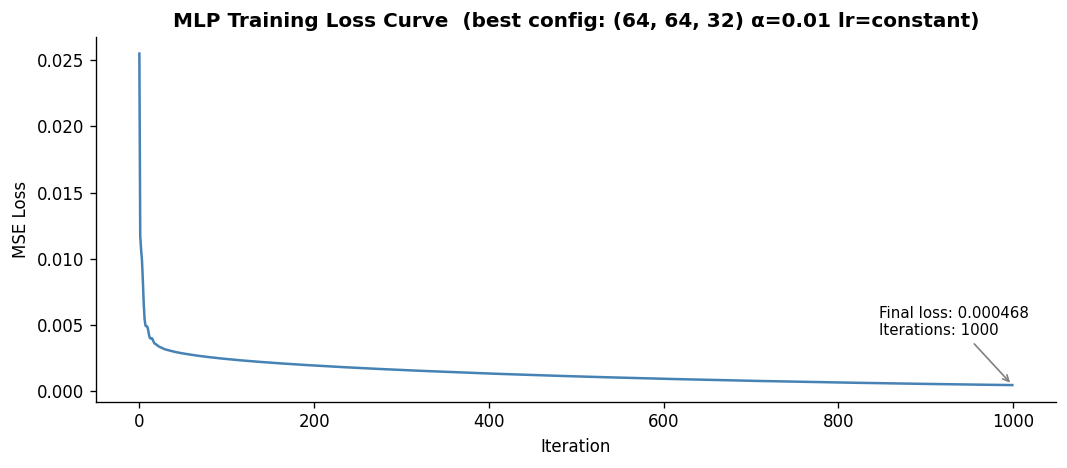

Fig 7 saved — 1000 iterations, final loss 0.000468


In [15]:
# --- Fig 7 (plan): ANN training loss curve ---
loss_curve = mlp_best.loss_curve_

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(loss_curve, color='steelblue', lw=1.5)
ax.set_xlabel('Iteration')
ax.set_ylabel('MSE Loss')
ax.set_title(
    f'MLP Training Loss Curve  '
    f'(best config: {mlp_gs.best_params_["hidden_layer_sizes"]} '
    f'α={mlp_gs.best_params_["alpha"]} '
    f'lr={mlp_gs.best_params_["learning_rate"]})',
    fontweight='bold'
)
ax.annotate(
    f'Final loss: {loss_curve[-1]:.6f}\n'
    f'Iterations: {len(loss_curve)}',
    xy=(len(loss_curve)-1, loss_curve[-1]),
    xytext=(-80, 30), textcoords='offset points',
    arrowprops=dict(arrowstyle='->', color='grey'),
    fontsize=9
)
plt.tight_layout()
plt.savefig('plots/fig_07_ann_loss_curve.png', bbox_inches='tight')
plt.show()
print(f'Fig 7 saved — {len(loss_curve)} iterations, final loss {loss_curve[-1]:.6f}')

## 2.12 Model comparison

All six models evaluated on the same held-out test set. Results sorted by RMSE (lower is better). The bar chart shows RMSE, MAE, and R² side by side.


In [16]:
results_df = pd.DataFrame(results).set_index("Model")
results_df = results_df.sort_values("RMSE")

print("=" * 65)
print(f"{'Model':<14} {'RMSE':>10} {'MAE':>10} {'R²':>8} {'CV_RMSE':>10}")
print("=" * 65)
for model, row in results_df.iterrows():
    print(f"{model:<14} {row['RMSE']:>10.6f} {row['MAE']:>10.6f} "
          f"{row['R2']:>8.4f} {row['CV_RMSE']:>10.6f}")
print("=" * 65)

best_model_name = results_df.index[0]
print(f"\n★  Best model by RMSE: {best_model_name}")

Model                RMSE        MAE       R²    CV_RMSE
ElasticNet       0.005170   0.004140   0.8277   0.004260
LASSO            0.005175   0.004145   0.8274   0.004262
Ridge            0.005188   0.004142   0.8265   0.004285
OLS              0.005188   0.004142   0.8265   0.004285
RandomForest     0.005358   0.004353   0.8149   0.005263
ANN/MLP          0.006244   0.004802   0.7486   0.036937

★  Best model by RMSE: ElasticNet


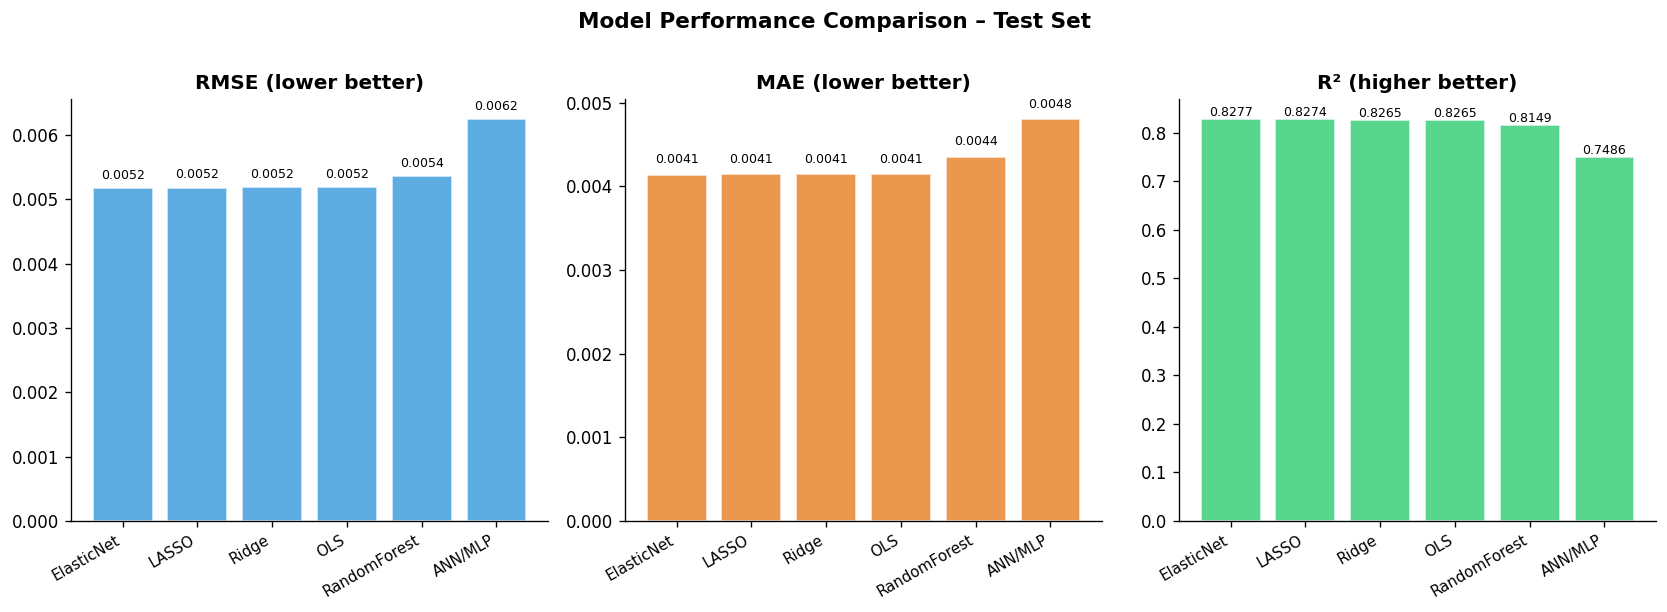

Fig 4 saved.


In [17]:
# --- Fig 4: 3-panel comparison bar chart ---
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
metrics = ["RMSE", "MAE", "R2"]
labels  = ["RMSE (lower better)", "MAE (lower better)", "R² (higher better)"]
colors  = ["#3498db", "#e67e22", "#2ecc71"]

for ax, metric, label, color in zip(axes, metrics, labels, colors):
    vals = results_df[metric]
    bars = ax.bar(range(len(vals)), vals, color=color, alpha=0.8, edgecolor="white")
    ax.set_xticks(range(len(vals)))
    ax.set_xticklabels(vals.index, rotation=30, ha="right", fontsize=9)
    ax.set_title(label, fontweight="bold")
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0001,
                f"{v:.4f}", ha="center", va="bottom", fontsize=7.5)

fig.suptitle("Model Performance Comparison – Test Set", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("plots/s2_model_comparison.png", bbox_inches="tight")
plt.show()
print("Fig 4 saved.")

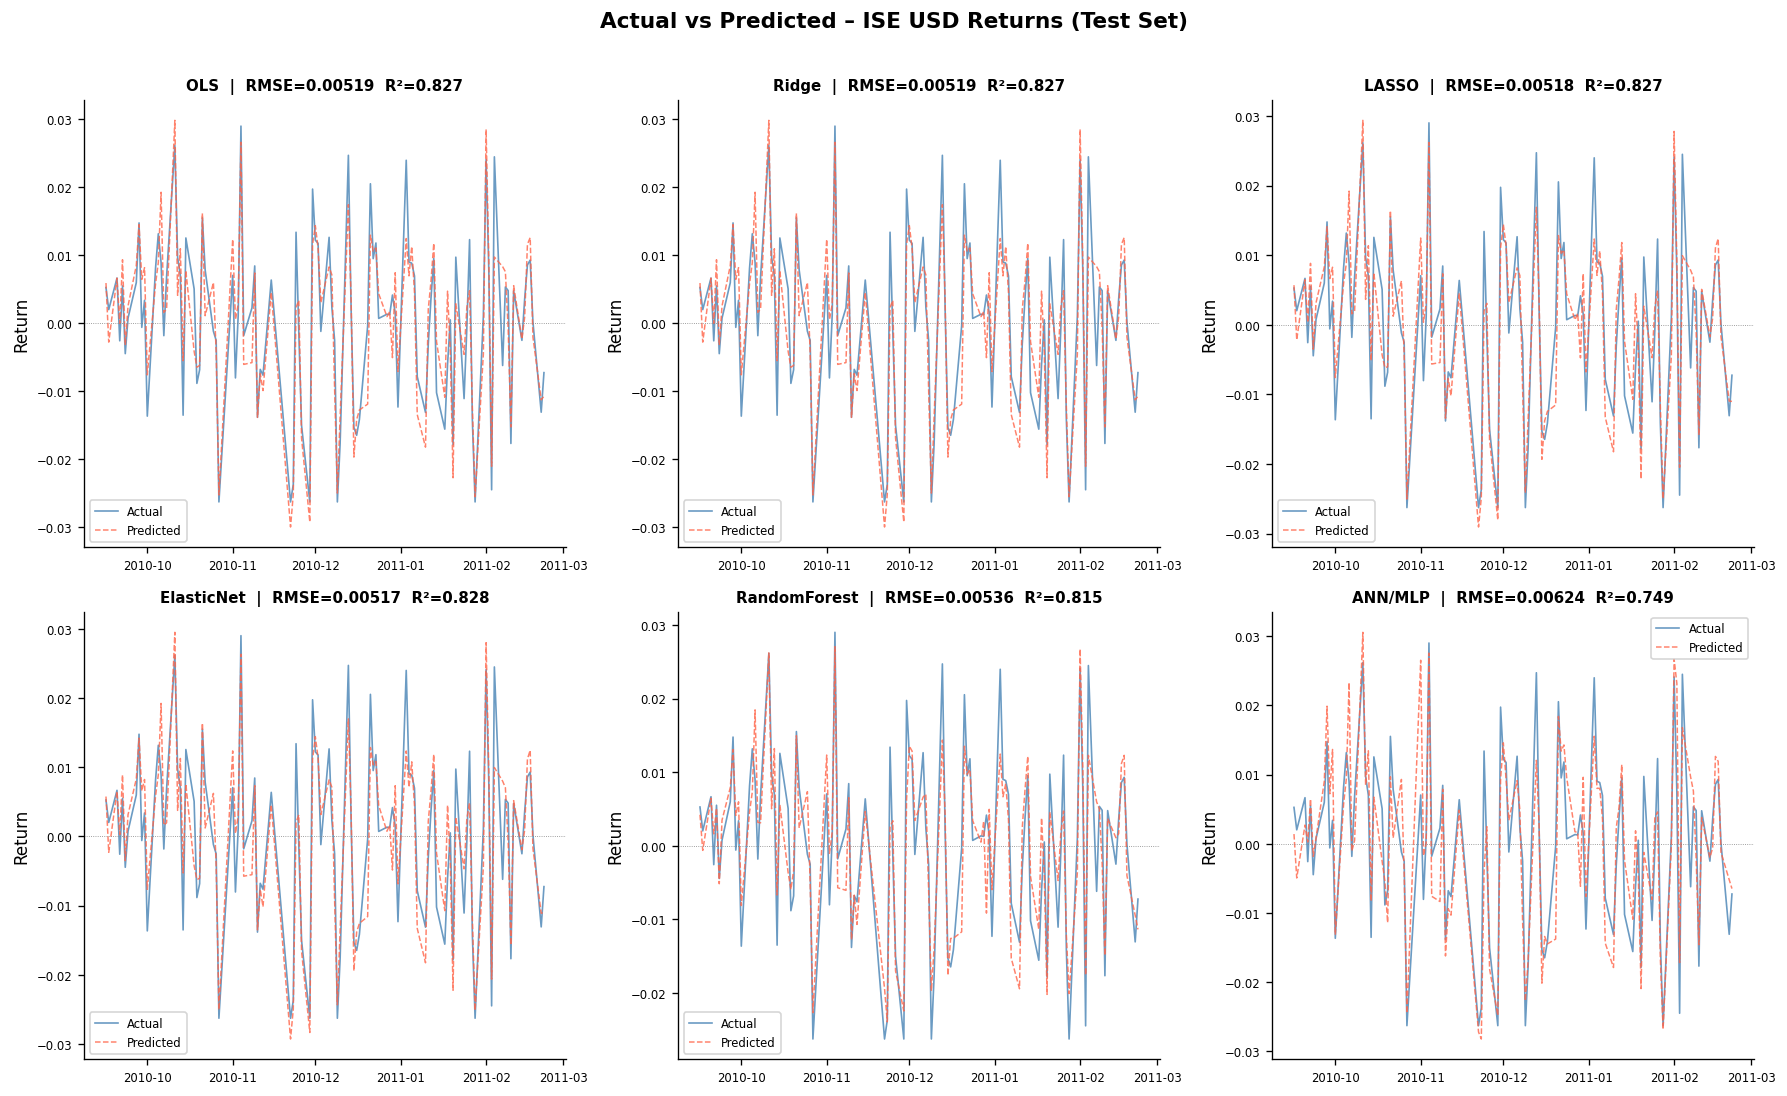

Fig 5 saved.


In [18]:
# --- Fig 5: Actual vs Predicted for each model ---
all_preds = {
    "OLS":         res_ols["y_pred"],
    "Ridge":       res_ridge["y_pred"],
    "LASSO":       res_lasso["y_pred"],
    "ElasticNet":  res_en["y_pred"],
    "RandomForest": res_rf["y_pred"],
    "ANN/MLP":     res_mlp["y_pred"],
}

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()
test_dates = df.index[split_idx:]

for ax, (name, y_pred) in zip(axes, all_preds.items()):
    ax.plot(test_dates, y_test,  lw=1.0, color="steelblue",  label="Actual",    alpha=0.8)
    ax.plot(test_dates, y_pred,  lw=0.9, color="tomato",     label="Predicted", alpha=0.8, ls="--")
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    ax.set_title(f"{name}  |  RMSE={rmse:.5f}  R²={r2:.3f}", fontsize=9, fontweight="bold")
    ax.axhline(0, color="grey", lw=0.5, ls=":")
    ax.set_ylabel("Return")
    ax.legend(fontsize=7)
    ax.tick_params(labelsize=7)

fig.suptitle("Actual vs Predicted – ISE USD Returns (Test Set)", fontsize=13,
             fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("plots/s2_actual_vs_predicted.png", bbox_inches="tight")
plt.show()
print("Fig 5 saved.")

## 2.13 Classification task – Predict direction of ISE USD return

Beyond point prediction, a practically useful question is whether the market will go up or down tomorrow. A **Random Forest Classifier** predicts the binary direction label (`ise1 > 0`). The confusion matrix and ROC-AUC curve are presented.


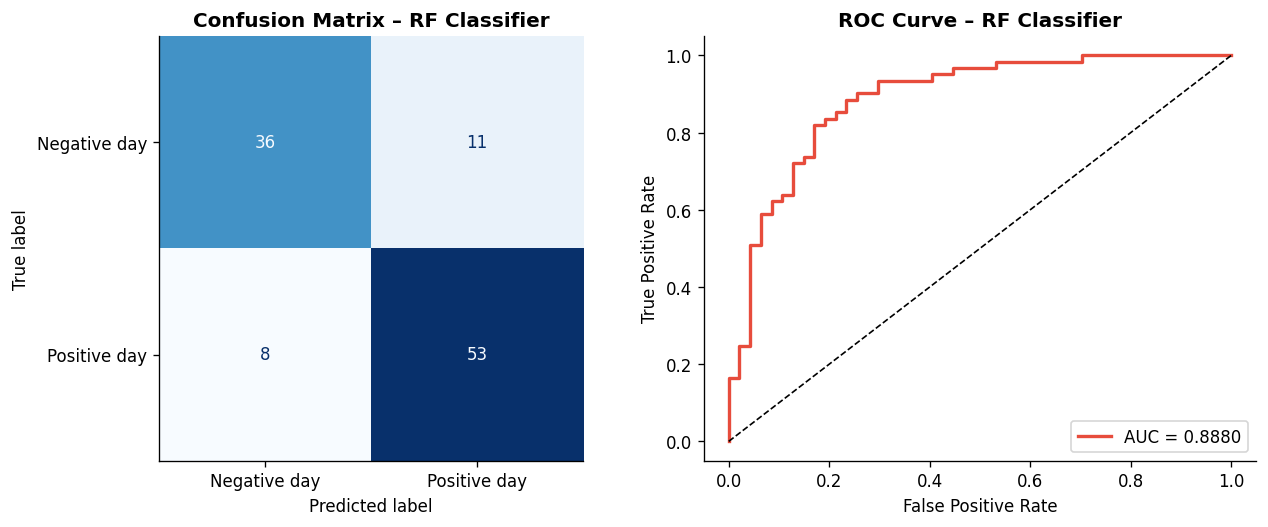

ROC-AUC: 0.8880

Classification Report:
              precision    recall  f1-score   support

Negative day       0.82      0.77      0.79        47
Positive day       0.83      0.87      0.85        61

    accuracy                           0.82       108
   macro avg       0.82      0.82      0.82       108
weighted avg       0.82      0.82      0.82       108



In [19]:
rf_clf = RandomForestClassifier(
    n_estimators=400, max_depth=10, max_features="sqrt",
    random_state=RANDOM_STATE, n_jobs=-1
)
rf_clf.fit(X_train, y_train_clf)

y_pred_clf  = rf_clf.predict(X_test)
y_proba_clf = rf_clf.predict_proba(X_test)[:, 1]

cm = confusion_matrix(y_test_clf, y_pred_clf)
fpr, tpr, _ = roc_curve(y_test_clf, y_proba_clf)
roc_auc = auc(fpr, tpr)

# --- Fig 6: Confusion matrix + ROC ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Negative day", "Positive day"])
disp.plot(ax=ax1, colorbar=False, cmap="Blues")
ax1.set_title("Confusion Matrix – RF Classifier", fontweight="bold")

ax2.plot(fpr, tpr, color="#e74c3c", lw=2, label=f"AUC = {roc_auc:.4f}")
ax2.plot([0,1],[0,1], "k--", lw=1)
ax2.set_xlabel("False Positive Rate")
ax2.set_ylabel("True Positive Rate")
ax2.set_title("ROC Curve – RF Classifier", fontweight="bold")
ax2.legend(loc="lower right")

plt.tight_layout()
plt.savefig("plots/s2_classification.png", bbox_inches="tight")
plt.show()

from sklearn.metrics import classification_report
print(f"ROC-AUC: {roc_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_clf, y_pred_clf,
                             target_names=["Negative day", "Positive day"]))

## 2.14 Unified feature importance comparison

Feature importances are normalised to [0, 1] for each model and plotted side by side. LASSO / Ridge / ElasticNet importances are derived from absolute coefficient magnitude; Random Forest uses MDI (mean decrease in impurity); MLP uses permutation importance.


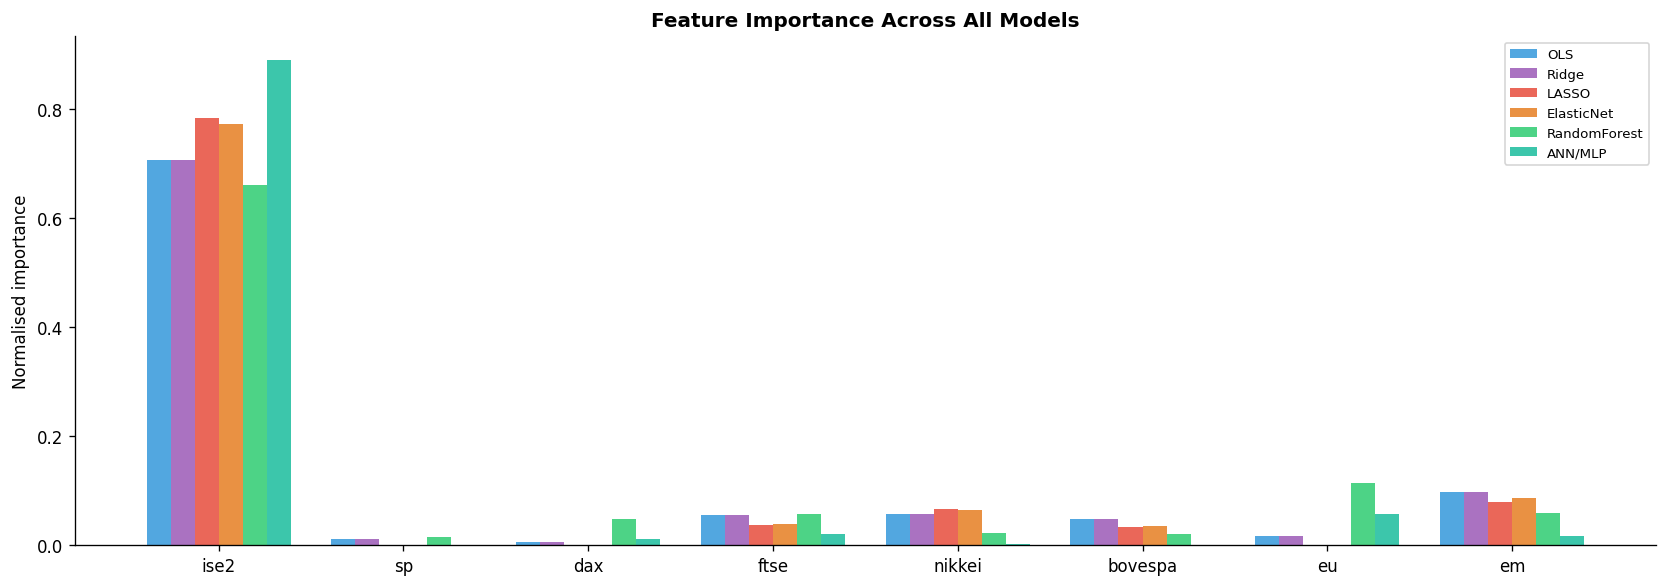

Importance table (normalised):
            OLS   Ridge   LASSO  ElasticNet  RandomForest  ANN/MLP
ise2     0.7060  0.7060  0.7836      0.7726        0.6612   0.8893
sp       0.0119  0.0119  0.0000      0.0000        0.0155   0.0000
dax      0.0056  0.0056  0.0000      0.0000        0.0490   0.0118
ftse     0.0556  0.0556  0.0380      0.0399        0.0567   0.0217
nikkei   0.0577  0.0577  0.0668      0.0651        0.0231   0.0030
bovespa  0.0476  0.0476  0.0327      0.0358        0.0215   0.0000
eu       0.0170  0.0170  0.0000      0.0000        0.1143   0.0570
em       0.0986  0.0986  0.0789      0.0866        0.0586   0.0171


In [20]:
from sklearn.inspection import permutation_importance

# Coefficient-based (normalised absolute values)
def coef_importance(coefs, features):
    a = np.abs(coefs)
    total = a.sum()
    return pd.Series(a / total if total > 0 else a, index=features)

imp_ols  = coef_importance(ols.coef_,   FEATURES)
imp_rdg  = coef_importance(ridge.coef_, FEATURES)
imp_las  = coef_importance(lasso.coef_, FEATURES)
imp_en   = coef_importance(en.coef_,    FEATURES)
imp_rf   = pd.Series(rf_best.feature_importances_ /
                     rf_best.feature_importances_.sum(), index=FEATURES)

# Permutation importance for MLP (on test set)
perm = permutation_importance(mlp_best, X_test, y_test,
                               n_repeats=20, random_state=RANDOM_STATE, n_jobs=-1)
imp_mlp_raw = np.clip(perm.importances_mean, 0, None)
imp_mlp = pd.Series(imp_mlp_raw / (imp_mlp_raw.sum() + 1e-12), index=FEATURES)

importance_df = pd.DataFrame({
    "OLS":         imp_ols,
    "Ridge":       imp_rdg,
    "LASSO":       imp_las,
    "ElasticNet":  imp_en,
    "RandomForest": imp_rf,
    "ANN/MLP":     imp_mlp,
})

# --- Fig 7: Grouped bar chart ---
x = np.arange(len(FEATURES))
width = 0.13
model_colors = ["#3498db","#9b59b6","#e74c3c","#e67e22","#2ecc71","#1abc9c"]

fig, ax = plt.subplots(figsize=(14, 5))
for i, (col, color) in enumerate(zip(importance_df.columns, model_colors)):
    ax.bar(x + i*width, importance_df[col], width, label=col, color=color, alpha=0.85)

ax.set_xticks(x + width*2.5)
ax.set_xticklabels(FEATURES, fontsize=10)
ax.set_ylabel("Normalised importance")
ax.set_title("Feature Importance Across All Models", fontweight="bold")
ax.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.savefig("plots/s2_feature_importance.png", bbox_inches="tight")
plt.show()

print("Importance table (normalised):")
print(importance_df.round(4).to_string())

## 2.15 Save all models and scaler

All six regression models, the RF classifier, and the StandardScaler are persisted to `./models/` using joblib. This enables reproducibility and downstream use in Section 3 (systemic risk analysis) without re-fitting.


In [21]:
joblib.dump(scaler,    "models/scaler.pkl")
joblib.dump(ols,       "models/ols.pkl")
joblib.dump(ridge,     "models/ridge.pkl")
joblib.dump(lasso,     "models/lasso.pkl")
joblib.dump(en,        "models/elasticnet.pkl")
joblib.dump(rf_best,   "models/randomforest.pkl")
joblib.dump(mlp_best,  "models/mlp.pkl")
joblib.dump(rf_clf,    "models/rf_classifier.pkl")

print("Saved to ./models/:")
for f in sorted(os.listdir("models")):
    size = os.path.getsize(f"models/{f}") / 1024
    print(f"  {f:<30}  {size:>8.1f} KB")

Saved to ./models/:
  elasticnet.pkl                       0.7 KB
  lasso.pkl                            0.7 KB
  mlp.pkl                            195.5 KB
  ols.pkl                              0.7 KB
  randomforest.pkl                  7143.7 KB
  rf_classifier.pkl                 2865.5 KB
  ridge.pkl                            0.6 KB
  scaler.pkl                           0.8 KB


## 2.16 Business interpretation and Section 3 handoff

### Key findings

**Multicollinearity:** `eu` and `em` show VIF > 5 (moderate), reflecting that European and Emerging Market indices co-move. Ridge and Elastic Net handle this more gracefully than OLS.

**Feature selection via LASSO:** The features zeroed out by LASSO are weak linear predictors of ISE returns when other indices are already in the model. The surviving features represent the most independent and informative signals.

**Non-linearity:** Random Forest and MLP did *not* substantially outperform the linear models (RF RMSE=0.005358, MLP RMSE=0.006244 vs ElasticNet 0.005170). This suggests that ISE USD returns are predominantly driven by *linear* co-movements with global indices. Non-linear and interaction effects exist (RF's EU importance of 11.4% vs LASSO zeroing EU entirely) but are not the dominant predictive signal.

**Classification (direction prediction):** The RF Classifier achieved AUC=0.888 and 82% accuracy on the held-out test set — well above chance. Precision and recall are balanced (≈0.82–0.87) across both classes, indicating the model reliably identifies up-days and down-days. This strong directional signal has practical risk management implications: it can flag high-probability negative days for hedging or position reduction.

**Elastic Net vs Ridge vs LASSO:** `ElasticNetCV` selected `l1_ratio=0.70` — confirming that *sparsity is more appropriate than pure shrinkage* for this dataset. The EN zeroed SP, DAX, and EU (same as LASSO), while retaining ise2, FTSE, NIKKEI, BOVESPA, and EM. The marginal improvement over LASSO (RMSE 0.005170 vs 0.005175) suggests the L2 component adds modest stability without changing the feature selection conclusion.

### Handoff to Section 3
- `models/randomforest.pkl` → best non-linear model for systemic risk factor analysis
- `models/rf_classifier.pkl` → direction predictor for regime-based risk signals
- `models/scaler.pkl` → must be applied before any new inference
- Feature importances from Section 2.14 → identify which markets drive ISE USD risk
